* Alessio Arcara
* alessio.arcara@studio.unibo.it

In [ ]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from kornia.losses import FocalLoss

# ── Project modules ───────────────────────────────────────────────────────────
from data.multi_epochs_dataloader import MultiEpochsDataLoader
from data.streethazards import (
    STREET_HAZARDS_CLASSES,
    StreetHazards,
    get_classes_as_dict,
)
from data.transforms import Denormalize, get_data_transforms
from models.detector import RunningCenters
from models.model import build_model
from training.losses import (
    ObjectosphereLoss,
    PrototypicalGlobalLocalTripletLoss,
)
from training.metrics import AUPR, MeanIoU
from training.trainer import Trainer
from utils.misc import fix_random, generate_run_name, get_device, load_config
from utils.visualize import (
    visualize_added_outlier,
    visualize_augmentations,
    visualize_centers,
)

# ── Environment configuration ────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

cv2.setNumThreads(0)
NUM_WORKERS: int = os.cpu_count() - 1

CONFIG_PATH = Path("./config.yaml")
config = load_config(CONFIG_PATH)
device = get_device()
fix_random(config["seed"])

TRAIN_ROOT = Path.home() / config["paths"]["train_path"]
TEST_ROOT = Path.home() / config["paths"]["test_path"]
TEST_ROOT = Path.home() / config["paths"]["test_path"]

common_loader_kwargs: dict = dict(
    batch_size=config["training"]["batch_size"],
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 CUDA device is available!


small survey about anomaly segmentation



Premessa: come il mio precedente notebook, link al notebook, sono interessato ad avere delle reti efficienti che mi permettano di poter trainare liberamente e fare diverse prove anche su un dispositivo mac con `mps`.

Guardando i diversi paper che ottenevano alti score nel benchmark SegmentMeIfYouCan, i migliori come mIoU utilizzano Mask classification e di conseguenza Mask2Former con l'aggiunta di un modulo o di tecniche per aggiungere anche il rilevamento di anomalie. Tra tutti ho preferito implementare il paper `Open Semantic Segmentation with Class Similarity` che ottiene un mIoU competitivo, rimanendo al contempo veloce a differenza degli approcci con Mask2Former più lenti di natura, e con un rilevamento di anomalie decisamente migliore. Successivamente, data la recente uscita del paper `Open Panoptic Segmentation`, sempre degli stessi autori, che oltre ad aggiungere la Panoptic Segmentation, risolve alcuni problemi del precedente approccio.

TODO

* Insert anomalies in validation set DONE
* mAP on anomalies
* open mIoU


fa fatica con i solar flare, potrai aggiungere una data augmentation nel training set e poi valutarla nell'ablation

In [31]:
data_transforms = get_data_transforms(
    img_height=config["training"]["img_height"],
    img_width=config["training"]["img_width"],
)
denorm = Denormalize()

train_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="training", transforms=data_transforms["train"]
)

val_data = StreetHazards(
    root_dir=TRAIN_ROOT, subset="validation", transforms=data_transforms["val"]
)

train_loader = MultiEpochsDataLoader(
    train_data,
    shuffle=True,
    drop_last=True,
    **common_loader_kwargs,
)

val_loader = MultiEpochsDataLoader(
    val_data,
    shuffle=False,
    drop_last=True,
    **common_loader_kwargs,
)

num_classes: int = len(STREET_HAZARDS_CLASSES) - 1
class_dict = get_classes_as_dict()

print(
    f"Samples        | train: {len(train_data):>6} | val: {len(val_data):>6}\n"
    f"Batches        | train: {len(train_loader):>6} | val: {len(val_loader):>6}\n"
    f"Known Classes  | {num_classes}"
)

Samples        | train:   5125 | val:   1031
Batches        | train:    854 | val:    171
Known Classes  | 13


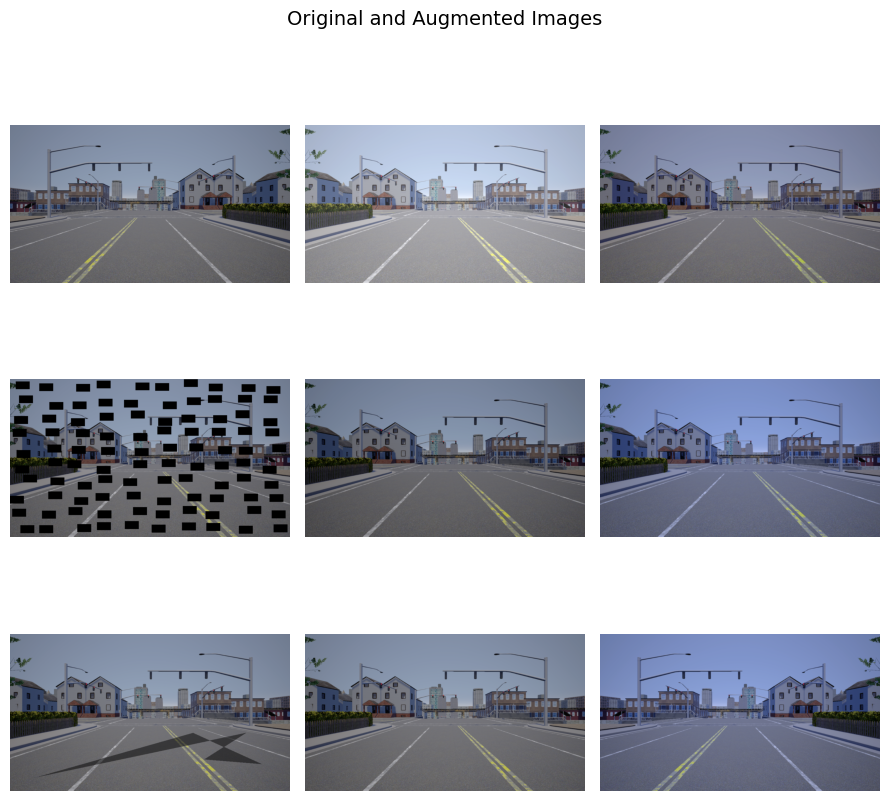

In [32]:
visualize_augmentations(train_data, data_transforms, denorm, num_samples=9)

COMMENTI:

* la wce converge meglio rispetto alla focal loss, ma risulta meno stabile e ogni tanto sul validation diverge decisamente
* best score right now on validation it's 0.55 mIoU,
* attualmente il mio modello fa fatica sulle parti lontane dell'immagine dove il modello non riesce a capire esattamente cosa c'è nell'immagine e sugli oggetti molto piccoli
* il modello non è preciso ai bordi, come affrontare il problema?
* aspp fa qualcosa?



In [16]:
do_train = False

model, model_info = build_model(config, num_classes)

criterions = [
    (
        1.0,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=config["losses"]["prototypical_triplet"]["global"],
            margin_local=config["losses"]["prototypical_triplet"]["local"],
            magnitude=config["losses"]["prototypical_triplet"]["anchors_magnitude"],
        ),
    ),
    (
        1.0,
        FocalLoss(
            alpha=config["losses"]["focal"]["alpha"],
            gamma=config["losses"]["focal"]["gamma"],
            reduction="mean",
        ),
    ),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader,
    criterions,
    denorm,
    val_loader,
    class_dict,
    [MeanIoU(num_classes)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train(run_name)
else:
    model.load_state_dict(
        torch.load(
            "saved/models/ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG1024x576_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss_20250424_055239_epoch50_miou0.7133.pt",
            weights_only=True,
        )
    )

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/efficientnet_b2.ra_in1k)
INFO:timm.models._hub:[timm/efficientnet_b2.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


$$
\mathcal{L}(x, y) = \Biggl \lbrace { \max \lbrace 0, \xi - \lVert F(x) \rVert \rbrace^2 \quad \text{if } y \geq 0 \atop \lVert F(x) \rVert_2^2 \hspace{3.7cm} \text{ otherwise } }
$$

In [ ]:
train_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="training",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

val_data_w_anomalies = StreetHazards(
    root_dir=TRAIN_ROOT,
    subset="validation",
    transforms=data_transforms["val"],
    add_anomalies=True,
)

train_loader_w_anomalies = MultiEpochsDataLoader(
    train_data_w_anomalies,
    shuffle=True,
    drop_last=True,
    **common_loader_kwargs,
)

val_loader_w_anomalies = MultiEpochsDataLoader(
    val_data_w_anomalies,
    shuffle=False,
    drop_last=True,
    **common_loader_kwargs,
)

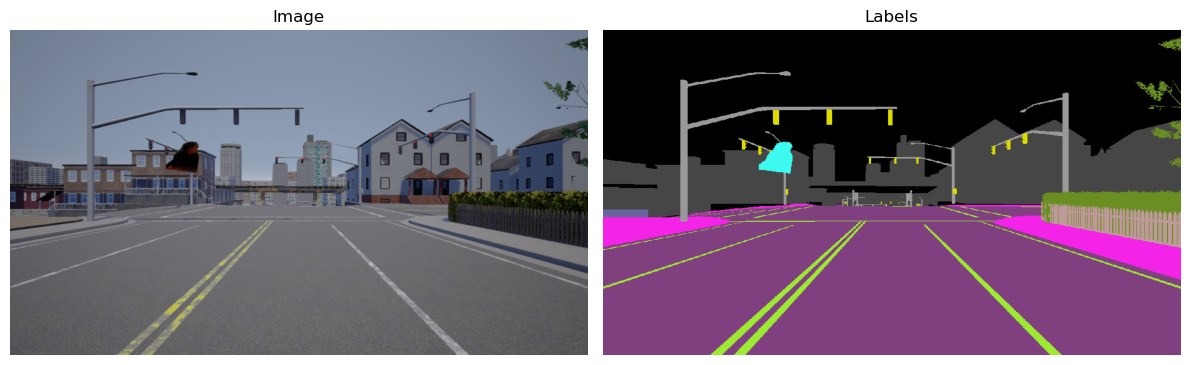

In [9]:
visualize_added_outlier(train_data_w_anomalies[0], denorm)

In [ ]:
do_train = False

criterions = [
    (
        0.45,
        PrototypicalGlobalLocalTripletLoss(
            num_classes=num_classes,
            margin_global=config["losses"]["prototypical_triplet"]["global"],
            margin_local=config["losses"]["prototypical_triplet"]["local"],
            magnitude=config["losses"]["prototypical_triplet"]["anchors_magnitude"],
        ),
    ),
    (
        0.45,
        FocalLoss(
            alpha=config["losses"]["focal"]["alpha"],
            gamma=config["losses"]["focal"]["gamma"],
            reduction="mean",
            ignore_index=13,
        ),
    ),
    (0.10, ObjectosphereLoss(xi=5.0, unknown_label=13)),
]

trainer = Trainer(
    config,
    model,
    device,
    train_loader_w_anomalies,
    criterions,
    denorm,
    val_loader_w_anomalies,
    class_dict,
    [MeanIoU(num_classes, ignore_index=13)],
    True,
)

if do_train:
    run_name = generate_run_name(config, model_info, criterions)
    trainer.train(f"OOD_{run_name}")
else:
    model.load_state_dict(
        torch.load(
            "saved/models/OOD_ENC_efficientnet_b2_DEC_2FAM64_ASPP12-24-36_IMG576x1024_LOSS_PrototypicalGlobalLocalTripletLoss,FocalLoss,ObjectosphereLoss_20250425_175255_epoch10_miou0.6953.pt",
            weights_only=True,
        )
    )

t classification approach takes advantage of the
label space induced by the LPTL, in which the KKC sam-
ples are projected closer to their corresponding prototypical
anchors. At the same time, the UUC samples are projected
toward the open space and, therefore, further away from the
prototypical anchors.

In [34]:
test_data = StreetHazards(
    root_dir=TEST_ROOT,
    subset="test",
    transforms=data_transforms["val"],
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    shuffle=False,
    **common_loader_kwargs,
)

print(
    f"Samples | test: {len(test_data):>6}\n"
    f"Batches | test: {len(test_loader):>6}\n"
)

Samples | test:   1500
Batches | test:    250



In [ ]:
centers = RunningCenters(num_classes)
centers.fit(model, train_loader, device)
visualize_centers(centers.centers)

Computing class centers:   0%|          | 0/854 [00:00<?, ?it/s]

RunningCenters()

In [ ]:
anchors = (
    torch.eye(num_classes, device="cuda")
    * config["losses"]["prototypical_triplet"]["anchors_magnitude"]
)


@torch.no_grad()
def anomaly_map(
    logits: torch.Tensor, anchors: torch.Tensor, threshold: float
) -> torch.Tensor:
    B, C, H, W = logits.shape
    device = logits.device
    anchors = anchors.to(device=device, dtype=logits.dtype)  # [K, C]

    embeds = logits.permute(0, 2, 3, 1).reshape(-1, C)  # [(B·H·W), C]

    # 1) norma al quadrato di ogni embedding
    norms_sq = embeds.norm(p=2, dim=1).pow(2)  # [(B·H·W)]

    # score continuo secondo s^cont = max(0, 1 - ||f||^2 / xi)
    cont_score = (1 - norms_sq / 5).clamp(min=0.0)

    # 2) distanze L2 verso gli anchor
    # [(B·H·W), K]
    dists = torch.cdist(embeds, anchors, p=2)
    min_dists, _ = dists.min(dim=1)  # [(B·H·W)]

    # rimodello tutto in (B, H, W)
    dist_map = min_dists.reshape(B, H, W)

    return dist_map

In [73]:
from tqdm.notebook import tqdm

metrics = [MeanIoU(num_classes, 13), AUPR(13)]
for imgs, masks in tqdm(test_loader):
    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    pred = torch.argmax(logits, dim=1)

    anomaly_prob = anomaly_map(logits, centers.centers, None)
    for metric in metrics:
        metric.update(anomaly_prob, pred, masks)

for metric in metrics:
    print(metric.compute())

  0%|          | 0/750 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 38.00 MiB. GPU 0 has a total capacity of 23.57 GiB of which 17.88 MiB is free. Including non-PyTorch memory, this process has 23.53 GiB memory in use. Of the allocated memory 22.92 GiB is allocated by PyTorch, and 312.26 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [78]:
import ipywidgets as widgets

from utils.visualize import COLORS, color

anchors = (
    torch.eye(num_classes, device="cuda")
    * config["losses"]["prototypical_triplet"]["anchors_magnitude"]
)


def visualize_predictions(model, dataset, device, threshold=0.5):
    model.eval()

    @torch.no_grad()
    def show_prediction(idx, threshold_value):
        """Funzione interna per visualizzare una singola predizione"""
        img, mask = dataset[idx]

        img = img.unsqueeze(0).to(device)

        with torch.inference_mode():
            logits = model(img)
            pred = torch.argmax(logits, dim=1)
            anomaly_probs = anomaly_map(logits, centers.centers, threshold_value)
            anomaly = anomaly_probs > threshold_value

        plt.figure(figsize=(15, 10))

        plt.subplot(231)
        plt.imshow(denorm(img))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(232)
        plt.imshow(color(mask.squeeze(), COLORS))
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(233)
        plt.imshow(color(pred.cpu().squeeze(), COLORS))
        plt.title("Predicted")
        plt.axis("off")

        plt.subplot(234)
        plt.imshow(anomaly.cpu().squeeze(), cmap="hot")
        plt.title("Anomaly Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    idx_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1, description="Indice:"
    )

    threshold_slider = widgets.FloatSlider(
        value=threshold, min=0.0, max=1.0, step=0.01, description="Threshold:"
    )

    widgets.interact(show_prediction, idx=idx_slider, threshold_value=threshold_slider)

In [79]:
anchors.shape

torch.Size([13, 13])

In [ ]:
visualize_predictions(model, test_data, "cuda")